# MG Boost Emulator Demo

This notebook demonstrates how to use the MG Boost Emulator to compute
the modified gravity boost to the matter power spectrum.

The emulator combines:
- A neural network (linear regime)
- A Gaussian Process (nonlinear regime)
- Smooth stitching across scales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


import sys
import os

sys.path.append(os.path.abspath(".."))

from emulator import MGEmulator



## Define Cosmology and load emulator

In [2]:
cosmo = {
    "Omega_m": 0.31,
    "Omega_b": 0.049,
    "h": 0.67,
    "n_s": 0.96,
    "A_s": 2.1e-9
}

mu = 1.05
eta = 1.0
bin_index = 2



In [3]:
zs = [0.0, 0.5, 1.0]

emu = MGEmulator(model_dir="../models")

k, boost = emu.predict_boost(
    cosmo,
    mu=mu,
    eta=eta,
    bin_index=bin_index,
    zs=zs
)

/home/sankarshana/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.1.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/sankarshana/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.1.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Plot Results

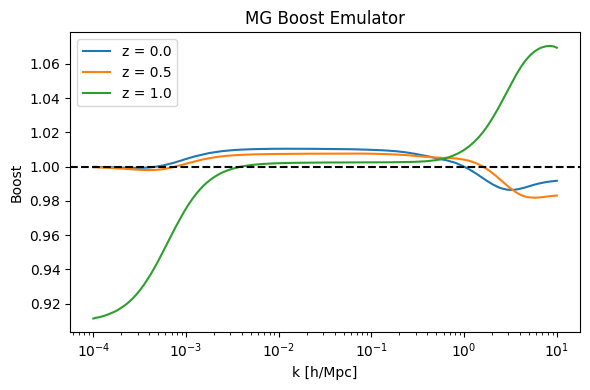

In [4]:
plt.figure(figsize=(6,4))

for i, z in enumerate(zs):
    plt.semilogx(k, boost[i], label=f"z = {z}")

plt.axhline(1.0, linestyle="--", color="black")

plt.xlabel("k [h/Mpc]")
plt.ylabel("Boost")
plt.title("MG Boost Emulator")

plt.legend()
plt.tight_layout()
plt.show()

## Plot $P(k)$ for different $\mu$ 

Time taken for mu=0.9: 0.12 seconds
Time taken for mu=1.1: 0.11 seconds


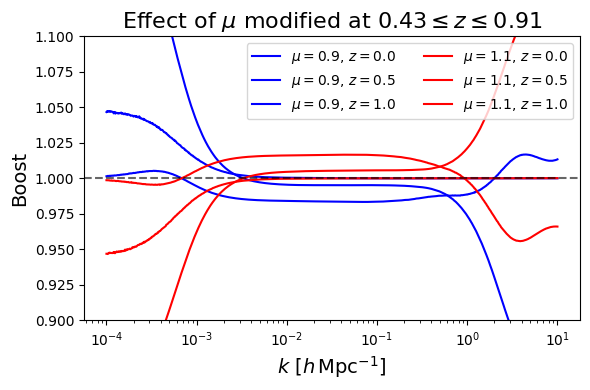

In [ ]:
mus = [0.9, 1.1]  # only the two you want

colors = {
    0.9: "blue",
    1.1: "red"
}

linestyles = {
    0.0: "-",
    0.5: "--",
    1.0: ":"
}

zs = [0.0, 0.5, 1.0]

plt.figure(figsize=(6,4))

for m in mus:

    k, boost = emu.predict_boost(
        cosmo,
        mu=m,
        eta=1.0,
        bin_index=1,
        zs=zs
    )

    for i, z in enumerate(zs):
        plt.semilogx(
            k,
            boost[i],
            color=colors[m],
            linestyle=linestyles[z],
            label=rf"$\mu={m},\, z={z}$"
        )
    

plt.axhline(1.0, linestyle="--", color="black", alpha=0.6)

plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=14)
plt.ylabel("Boost", fontsize=14)
plt.title(r"Effect of $\mu$ modified at $0.43 \leq z \leq 0.91$", fontsize=16)

plt.ylim(0.9, 1.1)

plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.savefig("../figures/boost_plot.png", dpi=300)
plt.show()

In [13]:
start = time.time()

k, boost = emu.predict_boost(
    cosmo,
    mu=1.1,
    eta=1.1,
    bin_index=3,
    zs=np.linspace(0.01, 3., 100)
)

end = time.time()
print(f"Time taken for prediction: {end - start:.2f} seconds")  

Time taken for prediction: 0.71 seconds
